In [ ]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.9 MB/s eta 0:00:00


In [ ]:
import numpy as np

texture = np.load("/content/texture_combined.npy")
stress  = np.load("/content/p_combined.npy")

print(texture.shape)  # (250,100,100,1)
print(stress.shape)   # (250,100,100,3,3)

(250, 100, 100, 1)
(250, 100, 100, 3, 3)


In [ ]:
all_s = stress.reshape(-1,3,3)

sigma = np.stack([
    all_s[:,0,0],
    all_s[:,1,1],
    all_s[:,2,2],
    all_s[:,0,1]
], axis=1)

stress_mean = sigma.mean(axis=0)
stress_std  = sigma.std(axis=0)

print("mean:", stress_mean)
print("std :", stress_std)

mean: [ 9.83525295e+08 -2.98498608e+03  7.05102028e+03 -1.24817443e+06]
std : [3.53088269e+08 3.56710267e+08 4.36130488e+08 1.92984015e+08]


In [ ]:
import torch
from torch_geometric.data import Data, Dataset

class CompositeDataset(Dataset):
    def __init__(self, texture, stress, mean, std):
        super().__init__()

        self.texture = texture
        self.stress  = stress
        self.mean = mean
        self.std  = std

        self.N = texture.shape[0]
        self.H = texture.shape[1]
        self.W = texture.shape[2]

        # grid coords
        xs, ys = np.meshgrid(np.arange(self.W), np.arange(self.H))
        coords = np.stack([xs, ys], axis=-1).reshape(-1,2)
        self.coords_norm = coords / max(self.H,self.W)

        # edges
        self.edge_index = self.build_edges(self.H,self.W)

        # edge features
        src = self.coords_norm[self.edge_index[0]]
        dst = self.coords_norm[self.edge_index[1]]
        d = src - dst
        dist = np.linalg.norm(d,axis=1,keepdims=True)

        self.edge_attr = torch.tensor(
            np.concatenate([d,dist],axis=1),
            dtype=torch.float32
        )

    def build_edges(self,H,W):
        edges=[]
        for i in range(H):
            for j in range(W):
                idx=i*W+j
                if i+1<H: edges.append([idx,(i+1)*W+j])
                if j+1<W: edges.append([idx,i*W+j+1])
                if i-1>=0: edges.append([idx,(i-1)*W+j])
                if j-1>=0: edges.append([idx,i*W+j-1])
        return torch.tensor(edges,dtype=torch.long).t()

    def len(self):
        return self.N

    def get(self, idx):

        # ----- modulus feature -----
        tex = self.texture[idx,:,:,0]
        phase = tex.reshape(-1)

        E = np.where(phase==2,200e9,10e9).reshape(-1,1)
        E_norm = E / 200e9

        node_feat = np.concatenate([self.coords_norm,E_norm],axis=1)

        # ----- stress 4 comps -----
        sig = self.stress[idx]
        s = sig.reshape(-1,3,3)

        y = np.stack([
            s[:,0,0],
            s[:,1,1],
            s[:,2,2],
            s[:,0,1]
        ],axis=1)

        y_norm = (y - self.mean) / self.std

        return Data(
            x=torch.tensor(node_feat,dtype=torch.float32),
            edge_index=self.edge_index,
            edge_attr=self.edge_attr,
            y=torch.tensor(y_norm,dtype=torch.float32)
        )

In [ ]:
dataset = CompositeDataset(texture,stress,stress_mean,stress_std)

data = dataset.get(0)
print(data.x.shape)  # (10000,3)
print(data.y.shape)  # (10000,4)

torch.Size([10000, 3])
torch.Size([10000, 4])


In [ ]:
import torch
from torch.nn import Sequential, Linear, ReLU, LayerNorm
from torch_geometric.nn import MessagePassing

class GraphNetBlock(MessagePassing):
    def __init__(self, latent):
        super().__init__(aggr="add")

        self.edge_mlp = Sequential(
            Linear(latent*3,latent),
            ReLU(),
            Linear(latent,latent),
            LayerNorm(latent)
        )

        self.node_mlp = Sequential(
            Linear(latent*2,latent),
            ReLU(),
            Linear(latent,latent),
            LayerNorm(latent)
        )

    def forward(self,x,edge_index,edge_attr):
        row,col=edge_index
        e=self.edge_mlp(torch.cat([x[row],x[col],edge_attr],dim=1))
        agg=self.propagate(edge_index,x=x,edge_attr=e)
        x_new=self.node_mlp(torch.cat([x,agg],dim=1))
        return x+x_new,e

    def message(self,edge_attr):
        return edge_attr

class GNN(torch.nn.Module):
    def __init__(self,node_in=3,edge_in=3,latent=64,steps=6,out=4):
        super().__init__()

        self.node_enc=Sequential(
            Linear(node_in,latent),
            ReLU(),
            Linear(latent,latent),
            LayerNorm(latent)
        )

        self.edge_enc=Sequential(
            Linear(edge_in,latent),
            ReLU(),
            Linear(latent,latent),
            LayerNorm(latent)
        )

        self.blocks=torch.nn.ModuleList(
            [GraphNetBlock(latent) for _ in range(steps)]
        )

        self.dec=Sequential(
            Linear(latent,latent),
            ReLU(),
            Linear(latent,out)
        )

    def forward(self,data):
        x=self.node_enc(data.x)
        e=self.edge_enc(data.edge_attr)

        for b in self.blocks:
            x,e=b(x,data.edge_index,e)

        return self.dec(x)

In [ ]:
from torch_geometric.loader import DataLoader
import random

N = 50   # number of samples you want to use

subset = [dataset[i] for i in range(N)]

idx = list(range(len(subset)))

#idx=list(range(len(dataset)))
random.shuffle(idx)

split=int(0.9*len(idx))
train=[dataset.get(i) for i in idx[:split]]
test =[dataset.get(i) for i in idx[split:]]

train_loader=DataLoader(train,batch_size=1,shuffle=True)
test_loader =DataLoader(test ,batch_size=1)

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=GNN().to(device)
opt=torch.optim.Adam(model.parameters(),lr=1e-3)

def train_epoch():
    model.train()
    tot=0
    for d in train_loader:
        d=d.to(device)
        pred=model(d)
        loss=torch.nn.functional.l1_loss(pred,d.y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        tot+=loss.item()
    return tot/len(train_loader)

for ep in range(10):
    print("Epoch",ep,train_epoch())

Epoch 0 0.7387421859635247
Epoch 1 0.6993755870395236
Epoch 2 0.6971874740388658
Epoch 3 0.6963942368825277
Epoch 4 0.6961724983321296
Epoch 5 0.6961722241507636
Epoch 6 0.6959258794784546
Epoch 7 0.696308245923784
Epoch 8 0.6955612540245056
Epoch 9 0.6961927798059252


In [ ]:
model.eval()
tot=0
with torch.no_grad():
    for d in test_loader:
        d=d.to(device)
        pred=model(d)
        tot+=torch.nn.functional.l1_loss(pred,d.y).item()

print("Test MAE:",tot/len(test_loader))

Test MAE: 0.6939257502555847


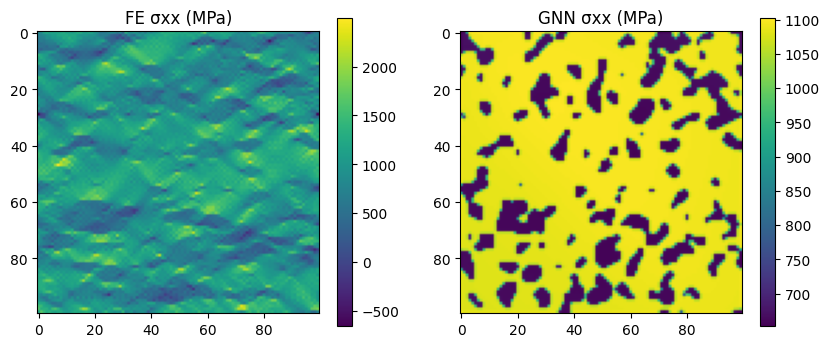

In [ ]:
import matplotlib.pyplot as plt

def denorm(y_norm,mean,std):
    return y_norm*std+mean

idx=0
data=dataset.get(idx).to(device)

with torch.no_grad():
    pred_norm=model(data)

pred=denorm(pred_norm.cpu().numpy(),stress_mean,stress_std)/1e6
truth=denorm(data.y.cpu().numpy(),stress_mean,stress_std)/1e6

H,W=dataset.H,dataset.W
comp=0  # σxx

pred_f=pred[:,comp].reshape(H,W)
true_f=truth[:,comp].reshape(H,W)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(true_f)
plt.title("FE σxx (MPa)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(pred_f)
plt.title("GNN σxx (MPa)")
plt.colorbar()

plt.show()

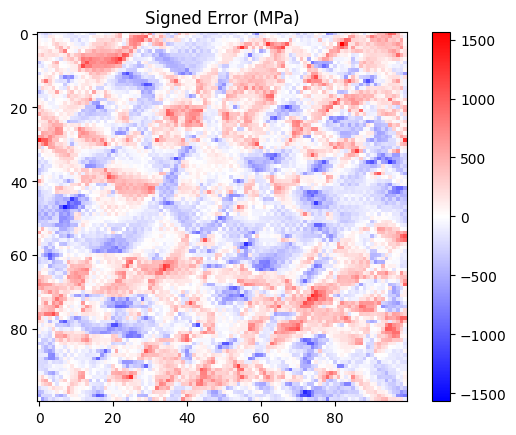

In [ ]:
err=pred_f-true_f
v=np.max(np.abs(err))

plt.imshow(err,cmap="bwr",vmin=-v,vmax=v)
plt.title("Signed Error (MPa)")
plt.colorbar()
plt.show()